In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('/home/armen/Downloads/telecom_churn.csv')
df
# g =sns.FacetGrid(df,  row='ContractRenewal', hue='Churn')
# g.map(sns.histplot, 'OverageFee')
# g.add_legend()
# plt.xticks(rotation=45)
# df['new']= df['MonthlyCharge'] / df['AccountWeeks']
# df['new2'] = df['OverageFee'] / df['MonthlyCharge']
# df['new3'] = df['MonthlyCharge'] / (df['DayMins'] + df['DataUsage'] )

df['new4'] = df['OverageFee'] >8
# df['new5'] = df['DayMins'] > 200
# df['new6'] = df['AccountWeeks'] > 100
df['new7'] = df['MonthlyCharge']>60





# df['new4'] = df['DayMins'] / df['DayCalls']
x = df.drop('Churn', axis=1)
y= df['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
rf = RandomForestClassifier(random_state=42).fit(x_train, y_train)
xgb = XGBClassifier(random_state=42, colsample_bytree= 0.8, learning_rate= 0.05, max_depth= 7, min_child_weight=3, 
                    n_estimators=200, scale_pos_weight=3, subsample=0.8).fit(x_train, y_train)
dc = DecisionTreeClassifier(random_state=42).fit(x_train, y_train)
lg= LogisticRegression(random_state=42).fit(x_train, y_train)





# params =  {
#     'n_estimators': [100, 200],
#     'max_depth': [5, 7, None],
#     'min_samples_split': [2, 5]
# }


# grid = GridSearchCV(rf, params, cv=5, scoring='f1').fit(x_train, y_train)
# best_params = grid.best_params_
# best_model = grid.best_estimator_
# rf_pred = best_model.predict(x_test)
# print('best model', best_model)
# print('rf f1_score :' , f1_score(y_test, rf_pred ))
# param_grid_xgb = {
#    'n_estimators': [200, 300],         # number of trees
#     'max_depth': [7, 10],                  # tree depth
#     'learning_rate': [0.05, 0.1],      # small to medium steps
#     'min_child_weight': [1, 3],          # balance small leaves
#     'subsample': [0.8],          # row sampling for regularization
#     'colsample_bytree': [0.8],   # feature sampling for regularization
#     'scale_pos_weight': [3]                  # 77/23 imbalance ratio
# }

# grid = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1').fit(x_train, y_train)
# best_params = grid.best_params_
# best_model =grid.best_estimator_
# xgb_pred = best_model.predict(x_test)
# print('best_params :', best_params)
# print('xgb f1_score :' , f1_score(y_test, xgb_pred))

# rf_pred = rf.predict(x_test)
# xgb_pred = xgb.predict(x_test)
# dc_pred =dc.predict(x_test)
# lg_pred = lg.predict(x_test)

# print('rf f1_score :', f1_score(y_test, rf_pred))       
# print('rf accuracy score :', accuracy_score(y_test, rf_pred))   
# print('xgb f1_score :', f1_score(y_test, xgb_pred))   
# print('xgb accuracy :', accuracy_score(y_test, xgb_pred))   
# print('dc f1_score :' , f1_score(y_test, dc_pred))    
# print('dc accuracy :', accuracy_score(y_test, dc_pred))  
# print('lg f1_score :', f1_score(y_test, lg_pred))
# print('lg accuracy :', accuracy_score(y_test, lg_pred))

y_proba = xgb.predict_proba(x_test)[:, 1]
threshold = 0.6
xgb_pred_new = (y_proba >= threshold).astype(int)
print('xgb f1_score :' , f1_score(y_test, xgb_pred_new))

importances = pd.Series(xgb.feature_importances_, index=x_train.columns)
importances.sort_values(ascending=False)



scores = cross_val_score(xgb, x, y, cv=5, scoring='f1')
print('cross_val', scores)
cm= confusion_matrix(y_test, xgb_pred_new)
print('conf matrix', cm)
precision = precision_score(y_test, xgb_pred_new)
recall = recall_score(y_test, xgb_pred_new)
print('precision :' , precision)
print('recall :' , recall)
print('accuracy :', accuracy_score(y_test, xgb_pred_new))




/home/armen/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


xgb f1_score : 0.7533632286995515
cross_val [0.70526316 0.71111111 0.77419355 0.7251462  0.75555556]
conf matrix [[695  14]
 [ 41  84]]
precision : 0.8571428571428571
recall : 0.672
accuracy : 0.934052757793765


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/home/armen/Downloads/telecom_churn.csv')
df

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1
...,...,...,...,...,...,...,...,...,...,...,...
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0


In [1]:
# df['nor333'] = df['AccountWeeks']>100
# sns.countplot(data=df, x='nor333', hue='Churn')
# df['nor333']= df['DataUsage'] =0
sns.countplot(data=df, x='OverageFee', hue='Churn')

NameError: name 'sns' is not defined

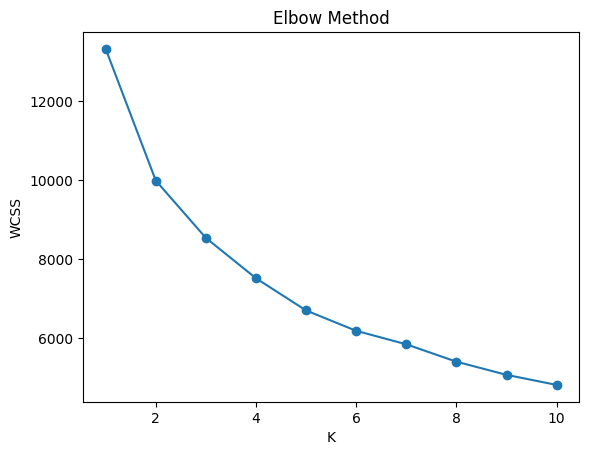

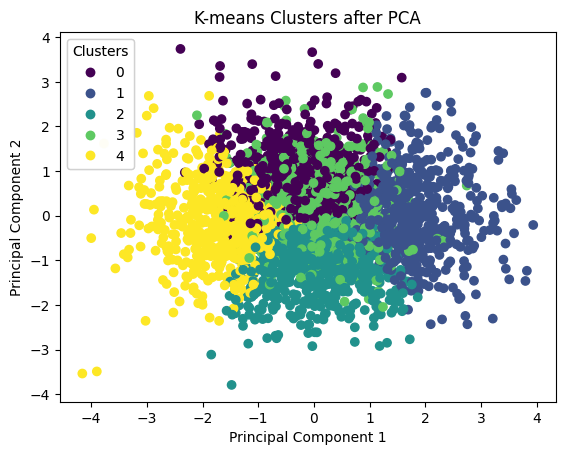

[[ 2.33879033e-02  7.06848327e-01  7.06978390e-01  7.28964480e-05]
 [ 7.04793578e-01 -6.78924029e-03 -1.66007592e-02  7.09185683e-01]]


Churn                0.000000
AccountWeeks       148.000000
ContractRenewal      1.000000
DataPlan             1.000000
DataUsage            4.100000
CustServCalls        2.000000
DayMins            244.900000
DayCalls           150.000000
MonthlyCharge       93.000000
OverageFee           5.900000
RoamMins            15.200000
Cluster_Raw          1.000000
PCA1                 2.452620
PCA2                 2.537329
score                4.989949
Name: 767, dtype: float64

In [22]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
df = pd.read_csv('/home/armen/Downloads/telecom_churn.csv')
df
x= df[['AccountWeeks', 'DayMins', 'MonthlyCharge', 'DayCalls']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
wcss= []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(x_scaled) 
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

k=5
model = KMeans(n_clusters=k, init='k-means++', random_state=42)
df['Cluster_Raw'] = model.fit_predict(x_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster_Raw'], cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clusters after PCA')
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)
plt.show()
print(pca.components_)
df.groupby('Cluster_Raw')[['AccountWeeks', 'DayMins', 'MonthlyCharge']].mean()
df['score'] = df['PCA1'] + df['PCA2']
df.loc[df['score'].idxmax()]

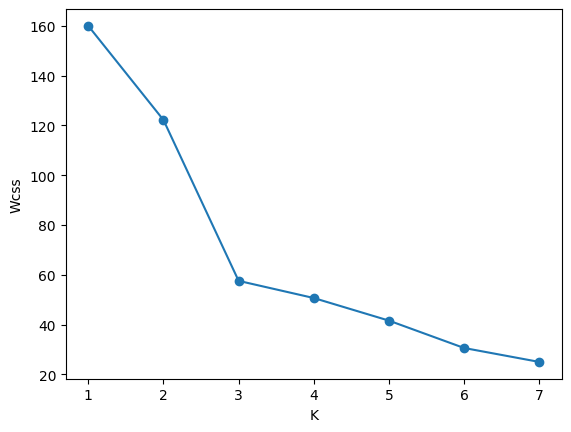

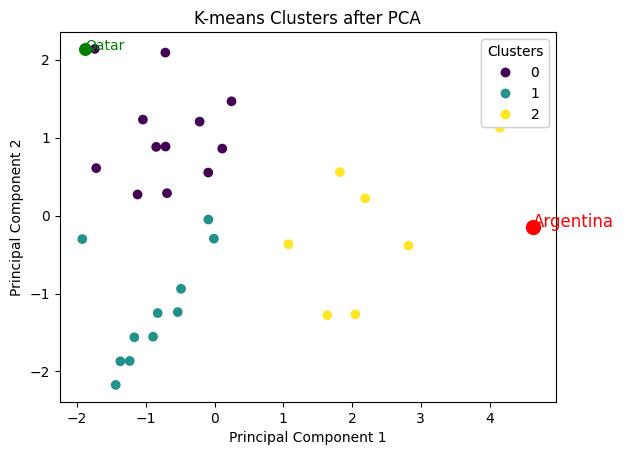

[[ 0.54749759  0.15500346 -0.13048834  0.56620106  0.5819016 ]
 [ 0.01582795  0.69835905  0.71249951  0.02195278 -0.06250308]]


,Goals For,Goals Against,Loss,Games Played,Win
Cluster_Raw,,,,,
0,3.538462,7.153846,2.153846,3.384615,0.923077
1,3.454545,3.090909,1.272727,3.272727,1.000000
2,11.000000,5.625000,1.500000,6.000000,3.875000


In [42]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
df = pd.read_csv('/home/armen/Downloads/FIFA - 2022.csv')
df
x= df[['Goals For', 'Goals Against', 'Loss', 'Games Played', 'Win']]
scaller = StandardScaler()
x_scaled = scaller.fit_transform(x)
wcss = []
for k in range(1, 8):
    kmeans= KMeans(n_clusters=k,  init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,8), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('Wcss')
plt.show() 

k=3
model= KMeans(n_clusters=k, init='k-means++', random_state=42)
df['Cluster_Raw'] =  model.fit_predict(x_scaled)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)


df['PCA1'] = x_pca[:, 0]
df['PCA2'] = x_pca[:, 1]

row = df[df['Team'] == 'Argentina'].iloc[0]
kow = df[df['Team'] == 'Qatar'].iloc[0]
scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster_Raw'], cmap='viridis')
plt.scatter(row['PCA1'], row['PCA2'], color='red', s=100)
plt.scatter(kow['PCA1'], kow['PCA2'], color='green', s=70 )
plt.text(row['PCA1'], row['PCA2'], 'Argentina', fontsize=12, color='red')
plt.text(kow['PCA1'], kow['PCA2'], 'Qatar', fontsize=10, color='green' )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clusters after PCA')
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1) 
plt.show()
print(pca.components_)
df.groupby('Cluster_Raw')[['Goals For', 'Goals Against', 'Loss', 'Games Played', 'Win']].mean()




In [38]:
df

,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,Cluster_Raw,PCA1,PCA2
0,1,Argentina,7,6,0,1,15,8,7,18,2,4.635598,-0.139805
1,2,France,7,5,0,2,16,8,8,15,2,4.151269,1.128942
2,3,Croatia,7,4,2,1,8,7,1,14,2,2.821959,-0.385587
3,4,Morocco,7,4,1,2,6,5,1,13,2,2.191133,0.221874
4,5,England,5,3,1,1,13,4,9,10,2,2.047984,-1.266805
5,6,Netherlands,5,3,1,1,10,4,6,10,2,1.639549,-1.278613
6,7,Portugal,5,3,0,2,12,6,6,9,2,1.822700,0.558341
7,8,Brazil,5,3,0,2,8,3,5,9,2,1.076072,-0.367714
8,9,Japan,4,2,0,2,5,4,1,6,1,-0.089659,-0.050076
9,10,Senegal,4,2,0,2,5,7,-2,6,0,0.112388,0.860236


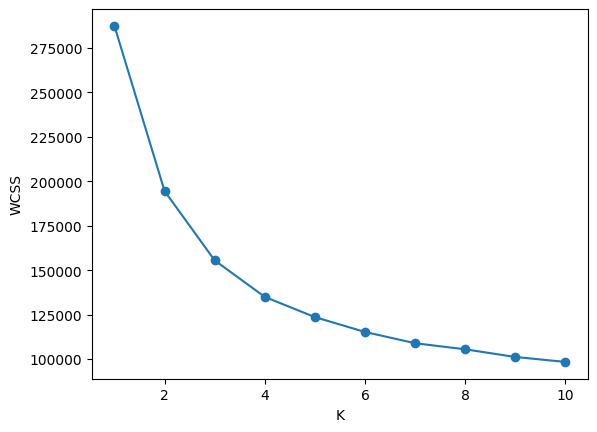

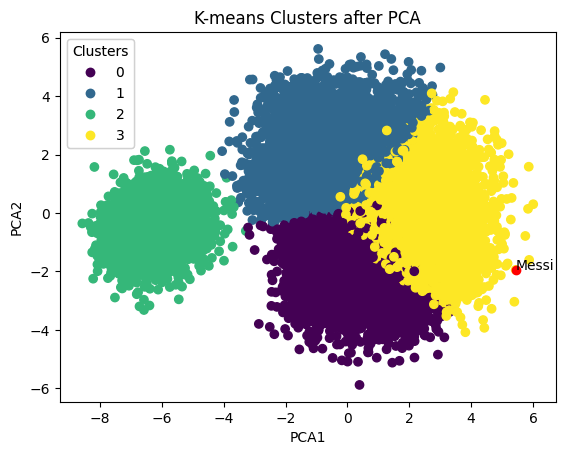

[[-0.14633051 -0.14163184  0.31379946  0.29684715  0.26481742  0.35140258
   0.35865803  0.28318427  0.29076511  0.31966779  0.18537407  0.12207716
   0.04684556  0.24082424  0.19812371  0.18454394]
 [ 0.23688438  0.33480182 -0.12810368 -0.17867613  0.27127625 -0.1119541
  -0.02099041 -0.14589014 -0.22408684 -0.09773805  0.15247014  0.19961106
   0.44252561  0.33951203  0.34290569  0.35223253]]


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
df = pd.read_csv('/home/armen/Downloads/fifa_players.csv.zip')
df = df.drop(['birth_date', 'full_name', 'international_reputation(1-5)', 'body_type', 
              'release_clause_euro', 'national_jersey_number', 'nationality', 'positions', 'national_team' , 'national_rating', 'national_team_position'
              ], axis=1)
df['value_euro'] = df['value_euro'].fillna(df['value_euro'].median())
df['wage_euro'] = df['wage_euro'].fillna(df['wage_euro'].median())
le = LabelEncoder()
df['preferred_foot'] = le.fit_transform(df['preferred_foot'])
x = df[['height_cm', 'weight_kgs', 'skill_moves(1-5)', 'finishing', 'heading_accuracy', 'dribbling', 'ball_control', 
        'sprint_speed' , 'agility', 'long_shots', 'reactions', 'jumping',  'strength', 'aggression', 'marking', 'standing_tackle']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)


plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()

k=4
model = KMeans(n_clusters=k, init='k-means++', random_state=42)
df['Cluster_Raw'] = model.fit_predict(x_scaled)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

df['PCA1'] = x_pca[:, 0]
df['PCA2'] = x_pca[:, 1]

row = df[df['name'] == 'L. Messi'].iloc[0]
scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster_Raw'], cmap='viridis')
plt.scatter(row['PCA1'], row['PCA2'], color='red')
plt.text(row['PCA1'], row['PCA2'], 'Messi')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('K-means Clusters after PCA')
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1) 
plt.show()
print(pca.components_)









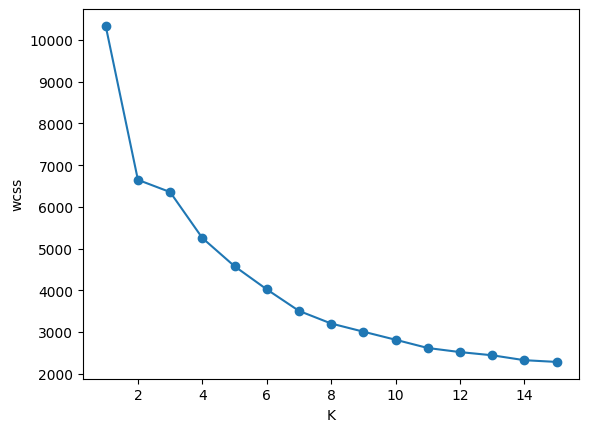

/home/armen/.local/lib/python3.13/site-packages/matplotlib/text.py:762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(x))
/home/armen/.local/lib/python3.13/site-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(y))
/home/armen/.local/lib/python3.13/site-packages/matplotlib/text.py:905: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/home/armen/.local/lib/python3.13/site-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.con

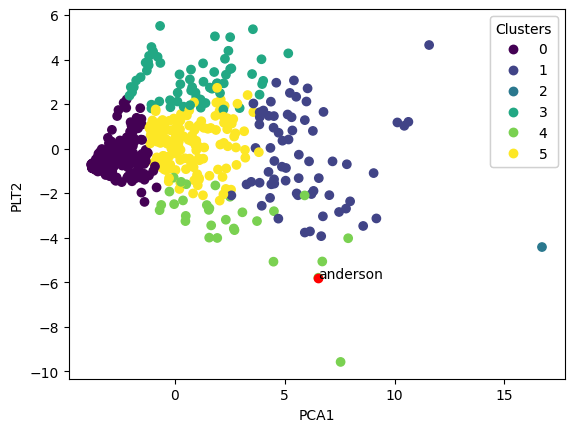

player_name                  Igor Thiago
position                               1
accurateCrosses                        5
accurateCrossesPercentage      41.666667
accurateFinalThirdPasses             120
                                ...     
wasFouled                             21
yellowCards                            6
Cluster_Raw                            4
PCA1                            6.529307
PCA2                           -5.801658
Name: 154, Length: 64, dtype: object
[[ 0.22033381  0.27504836  0.09211417  0.2093654   0.12929497  0.23058581
   0.1794973   0.25181069  0.27335968  0.16770532  0.1810166   0.23273562
   0.26840677  0.27872824  0.2178467   0.2230944   0.22865705  0.25590827
   0.21510609  0.23912447]
 [-0.01029903  0.09182748  0.37577552  0.35320013  0.17638494 -0.13496476
   0.30910287 -0.12697204 -0.08627329 -0.31266417 -0.3063089  -0.28342356
   0.06972356 -0.10228084 -0.13078824  0.20042589 -0.03067482  0.13512073
   0.35933843 -0.25344215]]


,accurateCrosses,accurateFinalThirdPasses,accurateLongBalls,accuratePasses,aerialDuelsWon,assists,ballRecovery,bigChancesCreated,expectedAssists,expectedGoals,goals,goalsAssistsSum,groundDuelsWon,keyPasses,successfulDribbles,tacklesWon,totalCross,totalDuelsWon,totalPasses,totalShots
Cluster_Raw,,,,,,,,,,,,,,,,,,,,
0,0.835616,26.611872,8.771689,129.200913,6.506849,0.219178,18.123288,0.383562,0.225396,0.843460,0.351598,0.570776,10.995434,2.342466,2.214612,3.369863,4.616438,17.502283,161.073059,4.456621
1,19.121212,271.893939,36.060606,794.378788,20.757576,3.166667,106.727273,6.409091,3.428157,3.343285,3.530303,6.696970,97.818182,32.939394,24.878788,25.909091,80.787879,118.575758,954.227273,34.984848
2,41.000000,530.000000,110.000000,1331.000000,18.000000,16.000000,138.000000,24.000000,9.076813,10.348600,8.000000,24.000000,93.000000,101.000000,15.000000,26.000000,133.000000,111.000000,1610.000000,73.000000
3,1.688525,134.918033,88.131148,1060.163934,52.688525,0.590164,127.000000,1.229508,0.795213,1.400302,0.950820,1.540984,43.180328,6.688525,3.836066,15.606557,6.540984,95.868852,1271.426230,10.803279
4,1.566667,111.200000,8.066667,273.033333,49.700000,1.700000,48.533333,2.766667,1.205785,8.611117,8.833333,10.533333,50.266667,16.433333,13.866667,8.833333,9.366667,99.966667,378.433333,48.633333
5,6.850000,132.092857,20.642857,486.957143,18.835714,1.364286,62.400000,2.135714,1.299422,1.446291,1.214286,2.578571,55.178571,13.664286,10.214286,17.514286,29.200000,74.014286,585.128571,15.535714


In [75]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
df = df = pd.read_csv('/home/armen/Downloads/premier_league_complete_stats_until31thGameDayOnSeason2025-26.csv',encoding='latin-1')
df = df.drop(['team_name', 'bigChancesMissed', 'cleanSheet', 'clearances', 'dispossessed', 'dribbledPast', 'errorLeadToGoal', 'errorLeadToShot',
          'freeKickGoal',  'goalsPrevented', 'headedGoals', 'highClaims', 'hitWoodwork', 'leftFootGoals', 'savesParried',
          'offsides', 'ownGoals', 'passToAssist', 'penaltiesTaken', 'penaltyConceded', 'penaltyConversion', 'setPieceConversion',
          'penaltyFaced', 'penaltyGoals', 'penaltySave', 'penaltyWon', 'possessionWonAttThird', 'punches', 'shotFromSetPiece',
          'redCards', 'rightFootGoals', 'savedShotsFromInsideTheBox', 'savedShotsFromOutsideTheBox', 'saves', 'savesCaught', 
          'shotsFromOutsideTheBox', 'shotsOffTarget', 'shotsOnTarget',], axis=1)
le = LabelEncoder()
df['position'] = le.fit_transform(df['position'])
df['expectedGoals'] = df['expectedGoals'].fillna(df['expectedGoals'].median())
df['expectedAssists'] = df['expectedAssists'].fillna(df['expectedAssists'].median())

x = df[['accurateCrosses', 'accurateFinalThirdPasses', 'accurateLongBalls',  'accuratePasses', 'aerialDuelsWon', 'assists', 'ballRecovery',
        'bigChancesCreated', 'expectedAssists', 'expectedGoals', 'goals', 'goalsAssistsSum', 'groundDuelsWon', 'keyPasses', 'successfulDribbles',
        'tacklesWon', 'totalCross', 'totalDuelsWon',  'totalPasses', 'totalShots']]

scaler =StandardScaler()
x_scaled = scaler.fit_transform(x)

wcss = []
for k in range(1,16):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,16), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('wcss')
plt.show()
k=6

model = KMeans(n_clusters=k, init='k-means++', random_state=42)
df['Cluster_Raw'] = model.fit_predict(x_scaled)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

df['PCA1'] = x_pca[: , 0]
df['PCA2'] =x_pca[: , 1]

row = df[df['player_name']== 'Igor Thiago']
scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster_Raw'], cmap='viridis')
plt.scatter(row['PCA1'], row['PCA2'], color='red')
plt.text(row['PCA1'], row['PCA2'], 'anderson')
plt.xlabel('PCA1')
plt.ylabel('PLT2')
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1) 
plt.show()    
idx = df['PCA2'].nsmallest(5).index[1]

print(df.loc[idx])

print(pca.components_)
df.groupby('Cluster_Raw')[['accurateCrosses', 'accurateFinalThirdPasses', 'accurateLongBalls',  'accuratePasses', 'aerialDuelsWon', 'assists', 'ballRecovery',
        'bigChancesCreated', 'expectedAssists', 'expectedGoals', 'goals', 'goalsAssistsSum', 'groundDuelsWon', 'keyPasses', 'successfulDribbles',
        'tacklesWon', 'totalCross', 'totalDuelsWon',  'totalPasses', 'totalShots']].mean()








